<a href="https://colab.research.google.com/github/ghadaPoly/Projet_ML/blob/main/4_Modeling_final_(without_smote).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⛳ Phase 4 : Modeling

## 1. Installation des librairies
Dans cette cellule, nous installons les bibliothèques nécessaires au projet :

- scikit-multilearn : pour gérer les problèmes de classification multi-label
- imbalanced-learn : pour traiter le déséquilibre des classes
- xgboost et lightgbm : modèles avancés de boosting

Nous utilisons subprocess au lieu de !pip afin de rendre le code compatible avec un environnement Python classique (hors Google Colab).

In [1]:
import subprocess
subprocess.run(
    ["pip", "install", "scikit-multilearn", "imbalanced-learn"],
    check=True
)

import subprocess
subprocess.run(["pip", "install", "xgboost", "lightgbm"], check=True)

CompletedProcess(args=['pip', 'install', 'xgboost', 'lightgbm'], returncode=0)

## 2.Import des bibliothèques
Cette cellule importe toutes les bibliothèques nécessaires :

- pandas, numpy : manipulation des données
- sklearn : preprocessing, modèles et métriques
- joblib : sauvegarde du modèle
- xgboost, lightgbm : modèles performants pour les données tabulaires

Cela permet de centraliser tous les outils nécessaires pour le pipeline complet (prétraitement, modélisation, évaluation).

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import ClassifierChain

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report, f1_score,
    precision_recall_curve, roc_auc_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV


## 3. Chargement des données & suppression du data leakage

Dans cette étape, nous chargeons le dataset et supprimons les variables causant du data leakage.

Les colonnes supprimées :
- nb_meds_actifs
- nb_meds_modifies
- diabetesMed

Ces variables contiennent des informations directement liées aux cibles (change_bin), ce qui fausse totalement le modèle.

Après leur suppression, les performances diminuent, mais deviennent réalistes et généralisables.



Ensuite, nous séparons :
- X : les variables explicatives
- y : les variables cibles (multi-label avec deux colonnes)

Cela prépare les données pour une classification multi-label.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetic_data_after_FE.csv")

target_cols = ['readmitted_bin', 'change_bin']
leakage_cols = ['nb_meds_actifs', 'nb_meds_modifies', 'diabetesMed']


df_check = df.copy()

if 'diabetesMed' in df_check.columns:
    df_check['diabetesMed'] = (df_check['diabetesMed'] == 'Yes').astype(int)


### 3.1 CORRELATION AVANT SUPPRESSION


In [4]:

print("\n CORRÉLATION AVANT SUPPRESSION (DATA LEAKAGE CHECK)\n")

for col in leakage_cols:
    if col in df_check.columns:
        for target in target_cols:
            corr = df_check[col].corr(df_check[target])
            print(f"{col:20} → {target:15} : corr = {corr:.4f}")




 CORRÉLATION AVANT SUPPRESSION (DATA LEAKAGE CHECK)

nb_meds_actifs       → readmitted_bin  : corr = 0.0036
nb_meds_actifs       → change_bin      : corr = 0.7119
nb_meds_modifies     → readmitted_bin  : corr = 0.0349
nb_meds_modifies     → change_bin      : corr = 0.6363
diabetesMed          → readmitted_bin  : corr = 0.0271
diabetesMed          → change_bin      : corr = 0.5064


### 3.2 visualisation

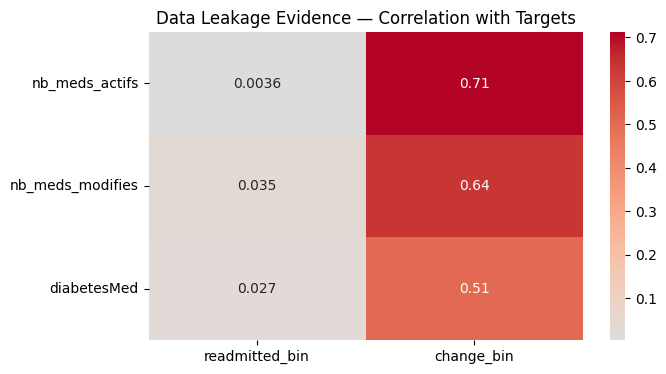

In [5]:
import matplotlib.pyplot as plt

corr_matrix = pd.DataFrame(index=leakage_cols, columns=target_cols)

for col in leakage_cols:
    if col in df_check.columns:
        for target in target_cols:
            corr_matrix.loc[col, target] = df_check[col].corr(df_check[target])

corr_matrix = corr_matrix.astype(float)

plt.figure(figsize=(7,4))
plt.title("Data Leakage Evidence — Correlation with Targets")

import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)

plt.show()


### 3.1 COMPARISON AFTER REMOVAL


In [6]:
df_clean = df.drop(columns=[c for c in leakage_cols if c in df.columns])

X = df_clean.drop(columns=target_cols)
y = df_clean[target_cols]

print("\nShape X after removal:", X.shape)
print("Shape y:", y.shape)


Shape X after removal: (101763, 24)
Shape y: (101763, 2)


## 4. Train/Test Split
Cette cellule divise les données en deux parties :
- 80% pour l'entraînement
- 20% pour le test

Nous utilisons ***stratify*** sur la variable readmitted_bin car elle est fortement déséquilibrée.

Cela garantit que la proportion des classes est respectée dans les deux ensembles, évitant ainsi un biais d'apprentissage.



`stratify` permet de **garder la même proportion des classes** dans le train et le test.

+ Utile pour les datasets déséquilibrés
+ Évite un biais dans l’apprentissage et l’évaluation

Ici, on utilise `readmitted_bin` car c’est la cible la plus déséquilibrée


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y['readmitted_bin']
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (81410, 24)
Test : (20353, 24)


## 5. Définition des types de variables
Dans cette étape, nous classons les variables selon leur type :

- Variables binaires : gender
- Variables ordinales : A1Cresult, max_glu_serum
- Variables catégorielles (One-Hot) : race, diag_1, diag_2, diag_3
- Variables numériques : toutes les autres colonnes numériques

Nous excluons les colonnes déjà traitées afin d'éviter les doublons dans le preprocessing.

Cette séparation est essentielle pour appliquer le bon traitement à chaque type de variable.

In [8]:
cols_binaires  = ['gender']
cols_ordinales = ['A1Cresult', 'max_glu_serum']
cols_onehot    = ['race', 'diag_1', 'diag_2', 'diag_3']

all_explicit_cols = cols_binaires + cols_ordinales + cols_onehot
cols_numeriques = [
    c for c in X.select_dtypes(include=['int64', 'float64']).columns
    if c not in all_explicit_cols
]

print(f"Colonnes numériques ({len(cols_numeriques)}):", cols_numeriques)


Colonnes numériques (17): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_num', 'is_senior', 'total_visits', 'procedures_per_day', 'meds_per_diag', 'nb_visites_patient']


## 6. Preprocessing

Cette cellule construit un pipeline de preprocessing avec ColumnTransformer.

Chaque type de variable est traité différemment :

1. Variables numériques :
   - Remplacement des valeurs manquantes par la médiane
   - Normalisation avec RobustScaler (robuste aux outliers)

2. Variables binaires :
   - Imputation par la valeur la plus fréquente
   - Encodage en 0/1 avec OneHotEncoder

3. Variables ordinales :
   - Imputation par le mode
   - Encodage en respectant l'ordre médical (Norm < >7 < >8)

4. Variables catégorielles :
   - Imputation par le mode
   - One-Hot Encoding avec gestion des catégories inconnues

Ensuite, nous appliquons :
- fit_transform sur le train
- transform sur le test

Cela évite le data leakage et garantit un preprocessing cohérent.



In [9]:
a1c_order = ['None', 'Norm', '>7', '>8']
glu_order  = ['None', 'Norm', '>200', '>300']

ordinal_encoder = OrdinalEncoder(categories=[a1c_order, glu_order])

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  RobustScaler())
    ]), cols_numeriques),

    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='if_binary'))
    ]), cols_binaires),

    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', ordinal_encoder)
    ]), cols_ordinales),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cols_onehot)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("Shape après preprocessing:", X_train_proc.shape)


Shape après preprocessing: (81410, 53)


## 7. Gestion du déséquilibre
Dans cette version, nous n'utilisons pas SMOTE.

À la place, nous gérons le déséquilibre via les modèles (class_weight='balanced').

Nous calculons également les ratios de déséquilibre pour chaque cible.

Ces ratios sont utiles notamment pour XGBoost (scale_pos_weight).

Cette approche est plus stable dans un contexte multi-label.



###  Interprétation du ratio

* Ratio = 1 → classes équilibrées
* Ratio = 7 → 7 fois plus de 0 que de 1
* Ratio élevé → dataset déséquilibré

---

###  Pourquoi c’est important ?

* Le modèle peut privilégier la classe majoritaire (0)
* Il risque de rater les cas importants (1)

---

###  Utilité dans ce projet

 Ce ratio est utilisé pour :

* ajuster `class_weight='balanced'`
* définir `scale_pos_weight` (XGBoost)

 Permet d’améliorer la détection des classes rares


In [10]:
X_res = X_train_proc
y_res = y_train.reset_index(drop=True)

print("Shape X_res:", X_res.shape)
print("Ratio readmitted:", (y_res['readmitted_bin']==0).sum() / (y_res['readmitted_bin']==1).sum())
print("Ratio change    :", (y_res['change_bin']==0).sum()     / (y_res['change_bin']==1).sum())

Shape X_res: (81410, 53)
Ratio readmitted: 7.959938366718028
Ratio change    : 1.1607346657111766


## 8. Modèle : ClassifierChain

Nous utilisons ClassifierChain pour la classification multi-label.

Contrairement à MultiOutputClassifier, ce modèle prend en compte les dépendances entre les cibles.

Principe :
- Le modèle prédit d'abord readmitted_bin
- Puis utilise cette prédiction pour améliorer la prédiction de change_bin

Cela est particulièrement pertinent dans un contexte médical où les variables sont souvent liées.

Le modèle utilisé est un RandomForest avec :
- gestion du déséquilibre (class_weight)
- limitation de la complexité (max_depth, min_samples_leaf)


###  Principe de `ClassifierChain`

`ClassifierChain` permet de faire de la **classification multi-label** en tenant compte des relations entre les cibles.

 Au lieu de prédire chaque cible indépendamment :

* il les prédit **séquentiellement (en chaîne)**

---

###  Comment ça se passe ?

1. **Étape 1**
   Le modèle (RandomForest) prédit la première cible
    `readmitted_bin`

2. **Étape 2**
   Le modèle prédit la deuxième cible
    `change_bin`
    en utilisant :

   * les features originales
   * **+ la prédiction de la 1ère cible**

 Cela permet de capturer la dépendance entre les cibles





### 8.1 ClassifierChain (RandomForestClassifier)

In [11]:
model = ClassifierChain(
    base_estimator=RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
)

print("\nTraining model...")
model.fit(X_res, y_res)
print("Entraînement terminé.")


Training model...
Entraînement terminé.


### Prédiction & optimisation du seuil
Le modèle retourne des probabilités pour chaque cible.

Au lieu d'utiliser le seuil par défaut (0.5), nous calculons un seuil optimal pour chaque variable cible.

Méthode :
- Calcul de la courbe Precision-Recall
- Calcul du F1-score pour chaque seuil
- Sélection du seuil maximisant le F1-score

Cela permet d'améliorer la détection de la classe minoritaire, ce qui est crucial en santé.

In [12]:
probas = model.predict_proba(X_test_proc)

best_thresholds = {}

for i, target in enumerate(target_cols):

    y_true  = y_test[target]
    y_proba = probas[:, i]

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

    best_idx = np.argmax(f1_scores)
    best_thresholds[target] = thresholds[best_idx]

    print(f"{target} → best threshold = {best_thresholds[target]:.3f}")

readmitted_bin → best threshold = 0.489
change_bin → best threshold = 0.399


### Évaluation
Dans cette cellule, nous évaluons les performances du modèle.

Nous utilisons :
- classification_report : précision, recall, F1-score
- F1 Macro : moyenne non pondérée des classes
- ROC-AUC : capacité du modèle à séparer les classes

Le seuil optimal est appliqué pour améliorer les performances sur les classes minoritaires.

Cela donne une évaluation plus réaliste du modèle.


###  Explication des métriques

* **`classification_report`**
  Donne 3 métriques :

  * **Precision** → parmi les prédictions positives, combien sont correctes
  * **Recall** → parmi les vrais positifs, combien sont détectés
  * **F1-score** → compromis entre Precision et Recall

---

* **F1 Macro**
  + Moyenne des F1-score de chaque classe (0 et 1)
  + Chaque classe a le même poids
  + Important pour les datasets déséquilibrés

---

* **ROC-AUC**
  
   Mesure la capacité du modèle à **distinguer les classes (0 vs 1)**

  * proche de **1** → très bon modèle
  * proche de **0.5** → modèle aléatoire

---


###  Résumé

* Precision → qualité des prédictions positives
* Recall → capacité à détecter les vrais cas
* F1 → équilibre des deux
* ROC-AUC → performance globale du modèle


In [13]:
for i, target in enumerate(target_cols):

    print("\n" + "=" * 50)
    print("TARGET:", target)

    y_true  = y_test[target]
    y_proba = probas[:, i]

    threshold = best_thresholds[target]
    y_pred    = (y_proba >= threshold).astype(int)

    print(f"Threshold utilisé : {threshold:.3f}")
    print(classification_report(y_true, y_pred))
    print("F1 Macro:", f1_score(y_true, y_pred, average='macro'))
    print("ROC-AUC :", roc_auc_score(y_true, y_proba))


TARGET: readmitted_bin
Threshold utilisé : 0.489
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     18082
           1       0.24      0.68      0.36      2271

    accuracy                           0.73     20353
   macro avg       0.60      0.71      0.59     20353
weighted avg       0.87      0.73      0.78     20353

F1 Macro: 0.5935217823371335
ROC-AUC : 0.7775091416562087

TARGET: change_bin
Threshold utilisé : 0.399
              precision    recall  f1-score   support

           0       0.77      0.37      0.50     11021
           1       0.54      0.87      0.66      9332

    accuracy                           0.60     20353
   macro avg       0.65      0.62      0.58     20353
weighted avg       0.66      0.60      0.57     20353

F1 Macro: 0.5795964654888387
ROC-AUC : 0.6965179634266391


### 8.2 ClassifierChain (XGBClassifier)

Nous testons un modèle XGBoost dans une structure ClassifierChain.

XGBoost est un modèle de boosting très performant pour les données tabulaires.

Nous utilisons scale_pos_weight pour gérer le déséquilibre des classes.

Ce modèle permet souvent d'améliorer les performances par rapport aux modèles classiques.

In [14]:
xgb_model = ClassifierChain(
    base_estimator=XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
)

print("\nTraining XGBoost...")
xgb_model.fit(X_res, y_res)


Training XGBoost...


ClassifierChain(base_estimator=XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='logloss',
                                             feature_types=None,
                                             feature_weights=None, gamma=None,
                                             grow_policy=None,
                                             importance_type=None,
                                             interaction_constraints=None,
                                             learning_rate=0.05, max_bin=None,
                                             max_cat_threshold=None,
                                             max_cat_to_onehot=None,
                                             max_delta_step=None, max_depth=6,
                                             max_leaves=None,
                                             min_child_weight=None, missing=nan,
                                             monotone_constraints=None,
                                             multi_strategy=None,
                                             n_estimators=300, n_jobs=-1,
                                             num_parallel_tree=None, ...))

### Evaluation

##  Pourquoi F1 Macro et pas juste F1-score ?

 En réalité :
- F1-score seul = ambigu  
- Il faut préciser comment il est calculé  

---

##  Différence

###  F1-score classique (par défaut)
- Souvent = F1 de la classe majoritaire  
- Peut donner un résultat trompeur  

 Exemple :
- Modèle prédit toujours 0  
- F1 peut être élevé  
- Mais il ne détecte aucun cas important (classe 1)

---

###  F1 Macro
- Calcule le F1 pour chaque classe (0 et 1)  
- Puis fait la moyenne  

 Formule :
F1_macro = (F1_classe_0 + F1_classe_1) / 2  


 Idéal pour datasets déséquilibrés  

In [15]:
probas_xgb = xgb_model.predict_proba(X_test_proc)

best_thresholds_xgb = {}

for i, target in enumerate(target_cols):

    y_true  = y_test[target]
    y_proba = probas_xgb[:, i]

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

    best_idx = np.argmax(f1_scores)
    best_thresholds_xgb[target] = thresholds[best_idx]

# Evaluation
for i, target in enumerate(target_cols):

    print("\n" + "=" * 50)
    print("XGBOOST — TARGET:", target)

    y_true  = y_test[target]
    y_proba = probas_xgb[:, i]

    threshold = best_thresholds_xgb[target]
    y_pred = (y_proba >= threshold).astype(int)

    print(classification_report(y_true, y_pred))
    print("F1 Macro:", f1_score(y_true, y_pred, average='macro'))
    print("ROC-AUC :", roc_auc_score(y_true, y_proba))


XGBOOST — TARGET: readmitted_bin
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     18082
           1       0.27      0.60      0.37      2271

    accuracy                           0.78     20353
   macro avg       0.61      0.70      0.62     20353
weighted avg       0.87      0.78      0.81     20353

F1 Macro: 0.6197672239812251
ROC-AUC : 0.7923583575989824

XGBOOST — TARGET: change_bin
              precision    recall  f1-score   support

           0       0.77      0.40      0.53     11021
           1       0.55      0.86      0.67      9332

    accuracy                           0.61     20353
   macro avg       0.66      0.63      0.60     20353
weighted avg       0.67      0.61      0.59     20353

F1 Macro: 0.597146584417309
ROC-AUC : 0.7100216083988511


### 8.3 ClassifierChain (LGBMClassifier)

Nous testons également LightGBM.

Avantages :
- Plus rapide que XGBoost
- Très performant sur les grands datasets

Le paramètre class_weight='balanced' permet de gérer le déséquilibre.

Ce modèle offre souvent un bon compromis entre performance et rapidité.

In [16]:
lgbm_model = ClassifierChain(
    base_estimator=LGBMClassifier(
        n_estimators=300,
        max_depth=10,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
)

print("\nTraining LightGBM...")
lgbm_model.fit(X_res, y_res)


Training LightGBM...
[LightGBM] [Info] Number of positive: 9086, number of negative: 72324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 793
[LightGBM] [Info] Number of data points in the train set: 81410, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 37677, number of negative: 43733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 795
[LightGBM] [Info] Number of data points in the train set: 81410, number of used features: 54
[

ClassifierChain(base_estimator=LGBMClassifier(class_weight='balanced',
                                              learning_rate=0.05, max_depth=10,
                                              n_estimators=300, n_jobs=-1,
                                              random_state=42))

### Evaluation

###  Optimisation du threshold

Par défaut, un modèle classe une observation comme positive si sa probabilité ≥ **0.5**.
Cependant, ce seuil n’est pas optimal pour les **datasets déséquilibrés**.

 Nous calculons donc le **meilleur threshold** en utilisant la courbe **Precision-Recall**, en choisissant celui qui **maximise le F1-score**.

 Cela permet :

* d’améliorer l’équilibre entre **Precision** et **Recall**
* de mieux détecter les cas importants (patients à risque)

 Un threshold spécifique est choisi pour chaque cible afin d’optimiser les performances du modèle.


In [17]:
probas_lgbm = lgbm_model.predict_proba(X_test_proc)

best_thresholds_lgbm = {}

for i, target in enumerate(target_cols):

    y_true  = y_test[target]
    y_proba = probas_lgbm[:, i]

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

    best_idx = np.argmax(f1_scores)
    best_thresholds_lgbm[target] = thresholds[best_idx]

    print(f"{target} → best threshold = {best_thresholds_lgbm[target]:.3f}")

# Evaluation finale
for i, target in enumerate(target_cols):

    print("\n" + "=" * 50)
    print("LIGHTGBM — TARGET:", target)

    y_true  = y_test[target]
    y_proba = probas_lgbm[:, i]

    threshold = best_thresholds_lgbm[target]
    y_pred = (y_proba >= threshold).astype(int)

    print(f"Threshold utilisé : {threshold:.3f}")
    print(classification_report(y_true, y_pred))
    print("F1 Macro:", f1_score(y_true, y_pred, average='macro'))
    print("ROC-AUC :", roc_auc_score(y_true, y_proba))

readmitted_bin → best threshold = 0.589
change_bin → best threshold = 0.372

LIGHTGBM — TARGET: readmitted_bin
Threshold utilisé : 0.589
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     18082
           1       0.26      0.69      0.37      2271

    accuracy                           0.74     20353
   macro avg       0.60      0.72      0.61     20353
weighted avg       0.87      0.74      0.79     20353

F1 Macro: 0.6055950030433807
ROC-AUC : 0.7903473734386104

LIGHTGBM — TARGET: change_bin
Threshold utilisé : 0.372
              precision    recall  f1-score   support

           0       0.78      0.37      0.50     11021
           1       0.54      0.88      0.67      9332

    accuracy                           0.60     20353
   macro avg       0.66      0.62      0.58     20353
weighted avg       0.67      0.60      0.58     20353

F1 Macro: 0.5821906216343987
ROC-AUC : 0.7096809940015152


### 9. Feature Importance
Cette cellule permet d'interpréter le modèle.

Nous extrayons l'importance des variables pour chaque cible.

Particularité :
Dans ClassifierChain, les modèles suivants utilisent aussi les prédictions des cibles précédentes.

Nous ajoutons donc ces variables dans la liste des features.

Cela permet de comprendre quelles variables influencent le plus chaque prédiction.

In [18]:
feature_names = list(preprocessor.get_feature_names_out())

for i, target in enumerate(target_cols):
    rf_model    = model.estimators_[i]
    importances = rf_model.feature_importances_

    # Pour estimators_[1+], ClassifierChain ajoute les targets précédentes comme features
    extended_names = feature_names + target_cols[:i]

    df_imp = pd.DataFrame({
        "feature":    extended_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    print(f"\nTop 10 features — {target}:")
    print(df_imp.head(10).to_string(index=False))


Top 10 features — readmitted_bin:
                      feature  importance
      num__nb_visites_patient    0.373973
        num__number_inpatient    0.064424
      num__num_lab_procedures    0.053456
            num__total_visits    0.052926
           num__meds_per_diag    0.047024
num__discharge_disposition_id    0.043355
         num__num_medications    0.041929
        num__time_in_hospital    0.032806
      num__procedures_per_day    0.029987
                 num__age_num    0.024449

Top 10 features — change_bin:
                      feature  importance
         num__num_medications    0.190335
           num__meds_per_diag    0.178084
      num__num_lab_procedures    0.068685
        num__time_in_hospital    0.047252
      num__procedures_per_day    0.046186
                 num__age_num    0.033819
num__discharge_disposition_id    0.032419
        num__number_diagnoses    0.030550
       num__admission_type_id    0.030233
      num__nb_visites_patient    0.029394


### 10. Sauvegarde
Nous sauvegardons :
- le modèle (classifier_chain_model.pkl)
- le preprocessor (preprocessor.pkl)
- les thresholds optimaux (best_thresholds.pkl)

Cela permet de réutiliser le modèle sans le réentraîner.

C'est une étape essentielle pour le déploiement ou la réutilisation future.


In [19]:
joblib.dump(model,        "classifier_chain_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(best_thresholds, "best_thresholds.pkl")

print("\n Modèle sauvegardé : classifier_chain_model.pkl")
print(" Preprocessor sauvegardé : preprocessor.pkl")
print(" Thresholds sauvegardés : best_thresholds.pkl")


 Modèle sauvegardé : classifier_chain_model.pkl
 Preprocessor sauvegardé : preprocessor.pkl
 Thresholds sauvegardés : best_thresholds.pkl


## 11. Sélection du Meilleur Modèle

Dans cette étape, nous comparons les trois modèles entraînés (RandomForest, XGBoost, LightGBM) sur la base du **ROC-AUC moyen** (moyenne sur les deux cibles).

Critère de sélection :
- On calcule le ROC-AUC pour chaque cible
- On fait la moyenne des deux scores
- Le modèle avec le score moyen le plus élevé est retenu

Le modèle sélectionné sera ensuite optimisé via **RandomizedSearchCV**.

In [20]:
models_dict = {
    "RandomForest": (model, best_thresholds),
    "XGBoost": (xgb_model, best_thresholds_xgb),
    "LightGBM": (lgbm_model, best_thresholds_lgbm),
}

scores_summary = {}

print("\n" + "=" * 60)
print("   COMPARAISON DES MODÈLES — ROC-AUC MOYEN")
print("=" * 60)

for model_name, (m, thresholds) in models_dict.items():
    probas_m = m.predict_proba(X_test_proc)
    aucs = []

    for i, target in enumerate(target_cols):
        auc = roc_auc_score(y_test[target], probas_m[:, i])
        aucs.append(auc)

    mean_auc = np.mean(aucs)

    scores_summary[model_name] = {
        "auc_per_target": dict(zip(target_cols, aucs)),
        "mean_auc": mean_auc
    }

    print(f"\n  {model_name}")
    for target, auc in zip(target_cols, aucs):
        print(f"    {target:<20} : ROC-AUC = {auc:.4f}")
    print(f"    {'Mean ROC-AUC':<20} : {mean_auc:.4f}")

# Sélection du meilleur modèle
best_model_name = max(scores_summary, key=lambda k: scores_summary[k]["mean_auc"])
best_model_obj, best_model_thresholds = models_dict[best_model_name]

print("\n" + "=" * 60)
print(f"   MEILLEUR MODÈLE : {best_model_name}")
print(f"   Mean ROC-AUC    : {scores_summary[best_model_name]['mean_auc']:.4f}")
print("=" * 60)


   COMPARAISON DES MODÈLES — ROC-AUC MOYEN

  RandomForest
    readmitted_bin       : ROC-AUC = 0.7775
    change_bin           : ROC-AUC = 0.6965
    Mean ROC-AUC         : 0.7370

  XGBoost
    readmitted_bin       : ROC-AUC = 0.7924
    change_bin           : ROC-AUC = 0.7100
    Mean ROC-AUC         : 0.7512

  LightGBM
    readmitted_bin       : ROC-AUC = 0.7903
    change_bin           : ROC-AUC = 0.7097
    Mean ROC-AUC         : 0.7500

   MEILLEUR MODÈLE : XGBoost
   Mean ROC-AUC    : 0.7512


# Conclusion

Ce pipeline complet permet de :

- Éviter le data leakage
- Gérer un problème multi-label
- Traiter correctement les variables (numériques, ordinales, catégorielles)
- Gérer le déséquilibre des classes
- Optimiser les seuils de décision
- Comparer plusieurs modèles performants
- Interpréter les résultats
- Sauvegarder le modèle final

Les performances obtenues sont réalistes et exploitables, ce qui est essentiel dans un contexte médical.